# LAB004–012 — auditoría del volumen líquido

Este notebook reconstruye un **escenario**, no un registro confirmado de pérdidas. Supone 65 mL netos por fila con etanol homologado finito (proxy de visita Alcolyzer). La procedencia de ETANOL, el volumen realmente no retornado, la primera muestra en t=0 y el volumen de solución nutritiva necesitan confirmación experimental. No ajusta parámetros ni cambia datos fuente.

El volumen inicial proviene del workbook cuando existe; para LAB007–009 el cargador usa 2 L por defecto. El Carbodoseur retornado no se contabiliza como pérdida. El volumen pequeño de Y15/Oculyze/mangueras queda en cero hasta disponer de registro.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

candidates = (Path.cwd(), Path.cwd() / 'volume_analysis',
              Path.cwd() / 'laboratory_2026' / 'notebooks' / 'volume_analysis',
              Path.cwd() / 'fermentation_model' / 'laboratory_2026' / 'notebooks' / 'volume_analysis')
notebook_dir = next((p for p in candidates if (p / '_volume_analysis.py').is_file()), None)
if notebook_dir is None:
    raise FileNotFoundError('Ejecutar desde el repositorio, notebooks o volume_analysis')
sys.path.insert(0, str(notebook_dir))
import _volume_analysis as va

ALCOLYZER_NET_LOSS_ML = 65.0  # hipótesis del laboratorio, pendiente de cotejar
FEED_SOLUTION_ML = 20.0    # ejemplo de sensibilidad, NO volumen medido
OTHER_LOSS_ML_PER_VISIT = 0.0  # Y15/Oculyze/mangueras sin registro aún
INCLUDE_T0_SAMPLE = True    # probar también False si los 2 L son posteriores a t=0

batches, tables = va.load_context()
labs = sorted(batches)
print('LAB cargados:', ', '.join(labs))
print('Nutrición: masa fija del protocolo; volumen de solución ilustrativo:', FEED_SOLUTION_ML, 'mL')

LAB cargados: LAB004, LAB005, LAB006, LAB007, LAB008, LAB009, LAB010, LAB011, LAB012
Nutrición: masa fija del protocolo; volumen de solución ilustrativo: 20.0 mL


In [2]:
ledgers = {
    lab: va.make_event_ledger(
        lab, tables, alcolyzer_ml=ALCOLYZER_NET_LOSS_ML,
        feed_ml=FEED_SOLUTION_ML,
        other_loss_ml_per_visit=OTHER_LOSS_ML_PER_VISIT,
        include_t0_sample=INCLUDE_T0_SAMPLE,
    )
    for lab in labs
}
summary = []
for lab, ledger in ledgers.items():
    samples = ledger[ledger.event.eq('sample')]
    feeds = ledger[ledger.event.eq('nutrition')]
    summary.append({
        'LAB': lab, 'V inicial (L)': ledger.initial_volume_l.iloc[0],
        'origen V inicial': ledger.initial_volume_source.iloc[0],
        'visitas con E finito (proxy)': int(samples.ethanol_observed.sum()),
        'pérdida modelada (mL)': -1000 * samples.volume_delta_l.sum(),
        'nutrición añadida (mL)': 1000 * feeds.volume_delta_l.sum(),
        'YAN añadido (mg)': 1000 * feeds.added_yan_g.sum(),
        'V final escenario (L)': ledger.volume_after_l.iloc[-1],
    })
summary = pd.DataFrame(summary)
display(summary.round(3))
display(ledgers['LAB004'][['time_h','event','sample_id','ethanol_observed','volume_delta_l','added_yan_g','volume_before_l','volume_after_l']].round(4))

,LAB,V inicial (L),origen V inicial,visitas con E finito (proxy),pérdida modelada (mL),nutrición añadida (mL),YAN añadido (mg),V final escenario (L)
0,LAB004,2.0,workbook,5,325.0,20.0,280.0,1.695
1,LAB005,2.0,workbook,5,325.0,20.0,280.0,1.695
2,LAB006,2.0,workbook,5,325.0,20.0,280.0,1.695
3,LAB007,2.0,default_2L,6,390.0,20.0,280.0,1.630
4,LAB008,2.0,default_2L,6,390.0,20.0,280.0,1.630
5,LAB009,2.0,default_2L,5,325.0,20.0,280.0,1.695
6,LAB010,2.0,workbook,4,260.0,20.0,280.0,1.760
7,LAB011,2.0,workbook,4,260.0,20.0,280.0,1.760
8,LAB012,2.0,workbook,4,260.0,20.0,280.0,1.760


,time_h,event,sample_id,ethanol_observed,volume_delta_l,added_yan_g,volume_before_l,volume_after_l
0,0.0000,sample,ING26-LAB004-01,True,-0.065,0.00,2.000,1.935
1,19.0000,sample,ING26-LAB004-02,False,-0.000,0.00,1.935,1.935
2,26.0000,sample,ING26-LAB004-03,False,-0.000,0.00,1.935,1.935
3,43.0000,sample,ING26-LAB004-04,False,-0.000,0.00,1.935,1.935
4,50.0000,sample,ING26-LAB004-05,True,-0.065,0.00,1.935,1.870
5,56.0917,nutrition,,False,0.020,0.28,1.870,1.890
6,67.0000,sample,ING26-LAB004-06,False,-0.000,0.00,1.890,1.890
7,74.0000,sample,ING26-LAB004-07,False,-0.000,0.00,1.890,1.890
8,91.0000,sample,ING26-LAB004-08,True,-0.065,0.00,1.890,1.825
9,98.0000,sample,ING26-LAB004-09,False,-0.000,0.00,1.825,1.825


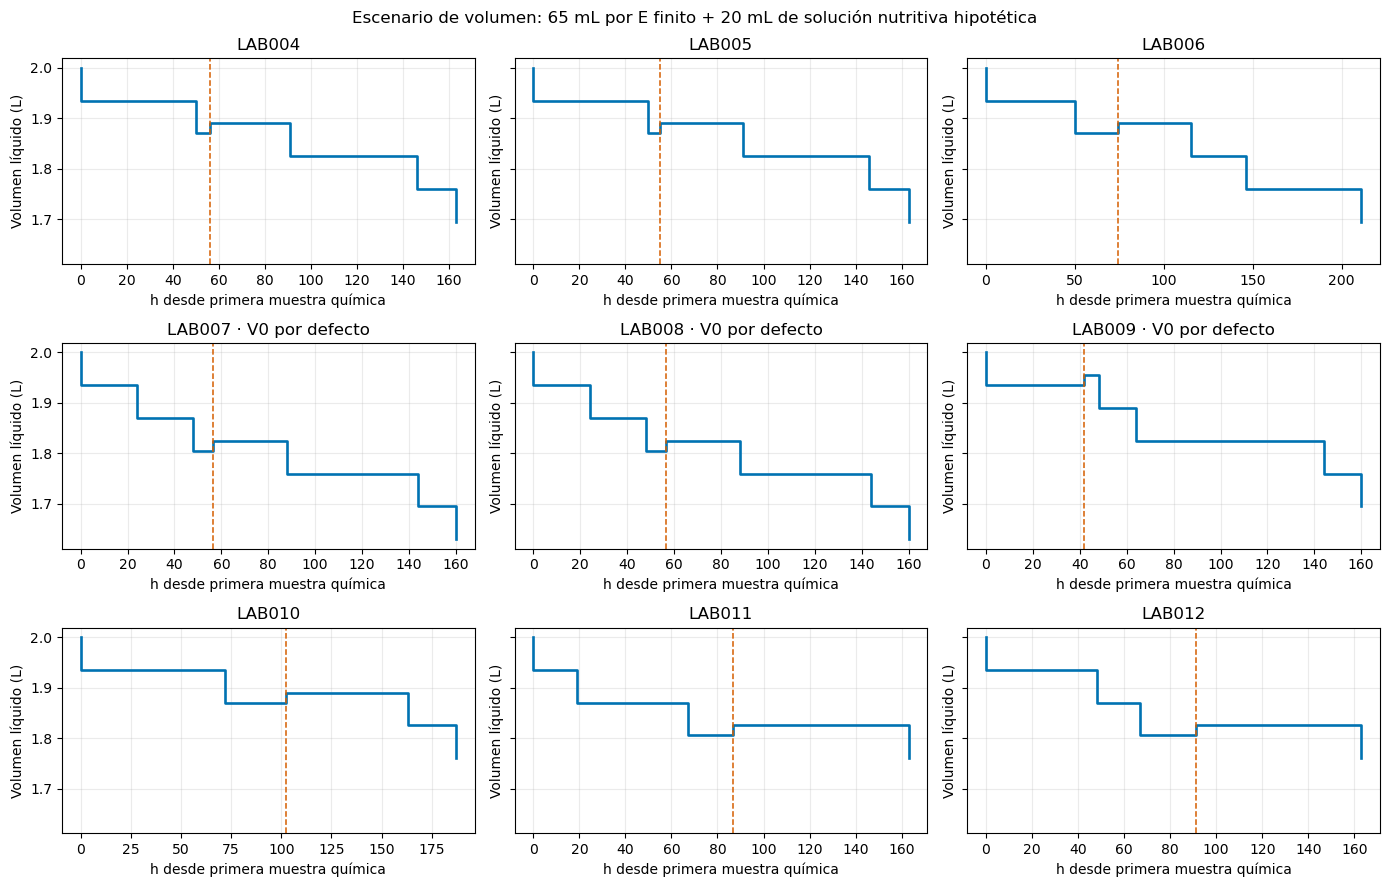

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(14, 9), sharey=True)
for ax, lab in zip(axes.flat, labs):
    ledger = ledgers[lab]
    times = np.r_[0.0, ledger.time_h.to_numpy(float)]
    volumes = np.r_[ledger.initial_volume_l.iloc[0], ledger.volume_after_l.to_numpy(float)]
    ax.step(times, volumes, where='post', color='#0072B2', lw=1.9)
    for t in ledger.loc[ledger.event.eq('nutrition'), 'time_h']:
        ax.axvline(t, color='#D55E00', ls='--', lw=1.1)
    ax.set_title(lab + (' · V0 por defecto' if ledger.initial_volume_source.iloc[0] == 'default_2L' else ''))
    ax.set_xlabel('h desde primera muestra química')
    ax.set_ylabel('Volumen líquido (L)')
    ax.grid(alpha=0.25)
fig.suptitle('Escenario de volumen: 65 mL por E finito + 20 mL de solución nutritiva hipotética')
fig.tight_layout()
plt.show()
plt.close(fig)

## Comprobaciones antes de usar este balance como dato

1. Verificar para cada LAB que cada E finito corresponde a una extracción real de Alcolyzer; en LAB010–012 la trazabilidad primaria del etanol es incompleta.
2. Confirmar si los 65 mL son netos y si incluyen Y15/Oculyze, purga y remanente de mangueras.
3. Confirmar si 2 L corresponde al volumen antes o después de la primera muestra, especialmente en LAB007–009 donde se usa un valor por defecto.
4. Sustituir 20 mL por el volumen real de solución o por cero si la adición fue sólida; mantener fija la masa realmente dosificada.

Ninguno de estos valores se escribe en los archivos de calibración desde este notebook.